In [1]:
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse

username = "root"
password = "Bisht@123"
host = "127.0.0.1"
port = "3306"
database = "banking_case"

encoded_password = urllib.parse.quote_plus(password)

engine = create_engine(f"mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}")

df = pd.read_sql("SELECT * FROM customers;", engine)

print(df.head())

  ï»¿Client ID             Name  Age  Location ID Joined Bank  \
0     IND81288    Raymond Mills   24        34324  06-05-2019   
1     IND65833    Julia Spencer   23        42205  10-12-2001   
2     IND47499   Stephen Murray   27         7314  25-01-2010   
3     IND72498   Virginia Garza   40        34594  28-03-2019   
4     IND60181  Melissa Sanders   46        41269  20-07-2012   

    Banking Contact Nationality            Occupation Fee Structure  \
0    Anthony Torres    American  Safety Technician IV          High   
1  Jonathan Hawkins     African   Software Consultant          High   
2     Anthony Berry    European    Help Desk Operator          High   
3        Steve Diaz    American          Geologist II           Mid   
4        Shawn Long    American   Assistant Professor           Mid   

  Loyalty Classification  ...  Bank Deposits  Checking Accounts  \
0                   Jade  ...     1485828.64          603617.88   
1                   Jade  ...      641482.79    

In [2]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [3]:
df.isna().sum()

ï»¿Client ID                0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df.shape

(3000, 25)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ï»¿Client ID              3000 non-null   str    
 1   Name                      3000 non-null   str    
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   str    
 5   Banking Contact           3000 non-null   str    
 6   Nationality               3000 non-null   str    
 7   Occupation                3000 non-null   str    
 8   Fee Structure             3000 non-null   str    
 9   Loyalty Classification    3000 non-null   str    
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loans         

In [7]:
bins=[0,100000,300000,float('inf')]
labels=['Low','Med','High']
df['Income_Band']=pd.cut(df['Estimated Income'],bins=bins,labels=labels,right=False)


<Axes: xlabel='Income_Band'>

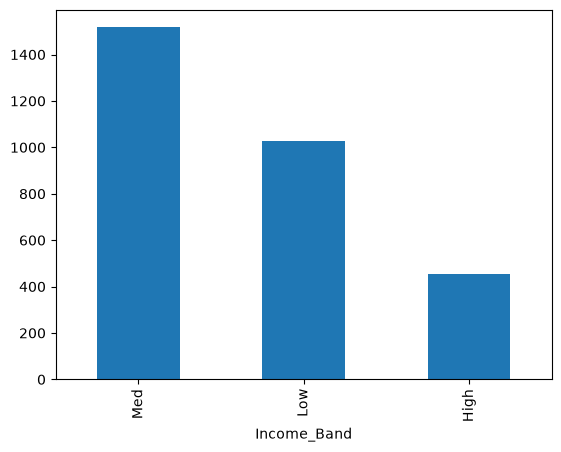

In [8]:
df['Income_Band'].value_counts().plot(kind='bar')

In [9]:
categorical_cols = df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification","Properties Owned","Risk Weighting","Income_Band"]].columns

In [10]:
for col in categorical_cols:
    print(col)
    print(df[col].value_counts())

BRId
BRId
3    1352
1     660
2     495
4     493
Name: count, dtype: int64
GenderId
GenderId
2    1512
1    1488
Name: count, dtype: int64
IAId
IAId
1     177
2     177
3     177
4     177
8     177
9     176
10    176
11    176
12    176
13    176
14    176
15    176
5      89
6      89
7      89
16     88
17     88
18     88
19     88
20     88
21     88
22     88
Name: count, dtype: int64
Amount of Credit Cards
Amount of Credit Cards
1    1922
2     765
3     313
Name: count, dtype: int64
Nationality
Nationality
European      1309
Asian          754
American       507
Australian     254
African        176
Name: count, dtype: int64
Occupation
Occupation
Associate Professor             28
Structural Analysis Engineer    28
Recruiter                       25
Account Coordinator             24
Human Resources Manager         24
                                ..
Office Assistant IV              8
Automation Specialist I          7
Computer Systems Analyst I       6
Developer III       

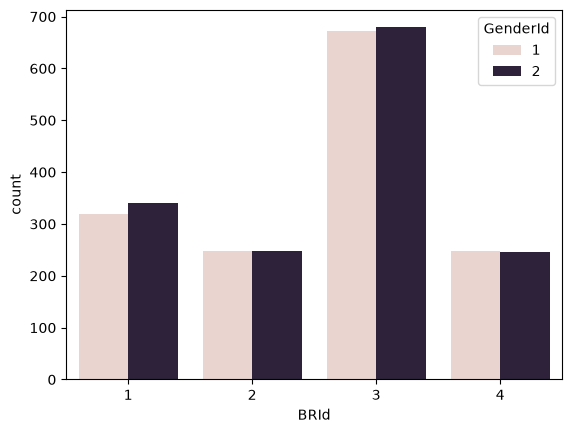

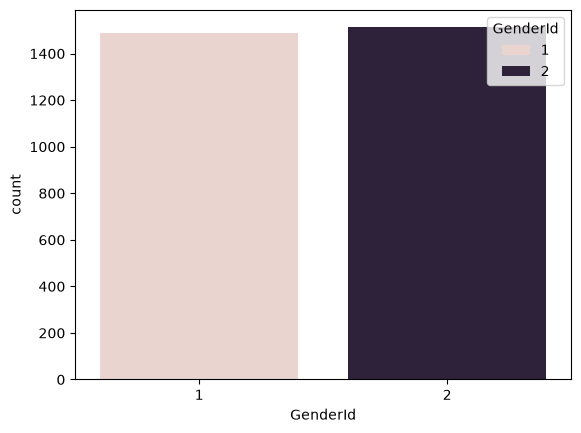

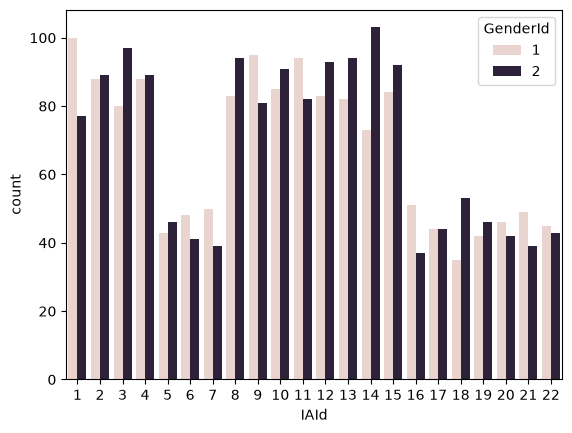

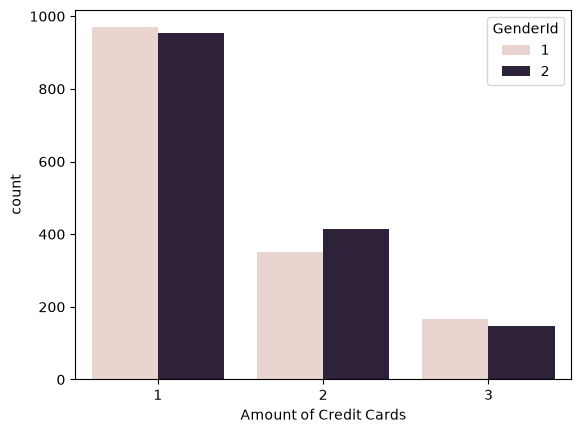

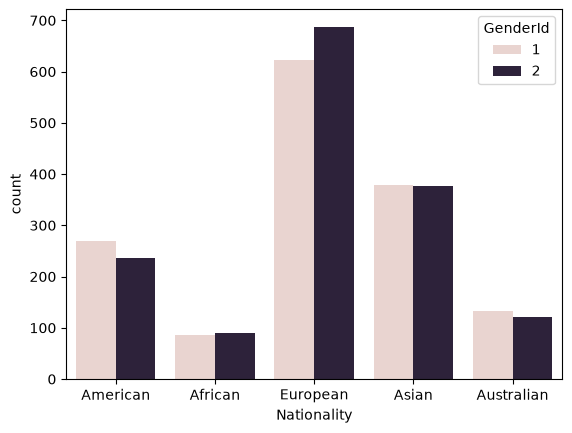

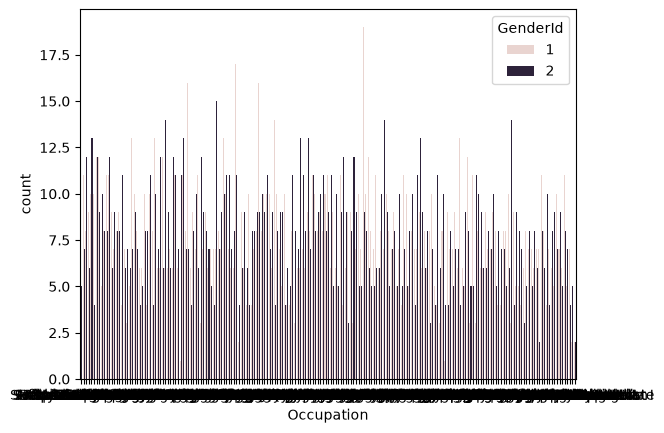

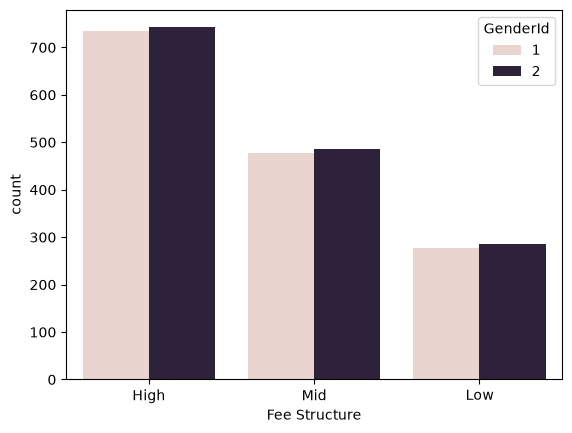

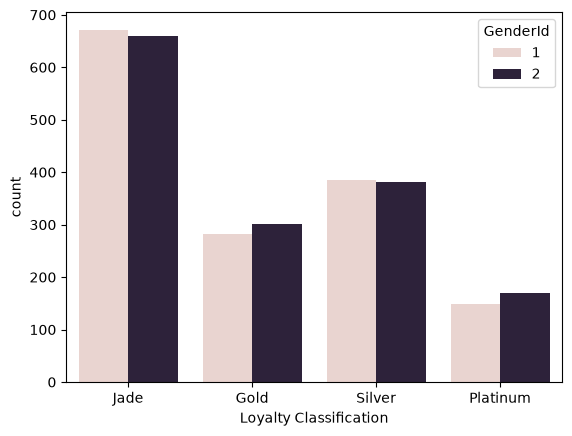

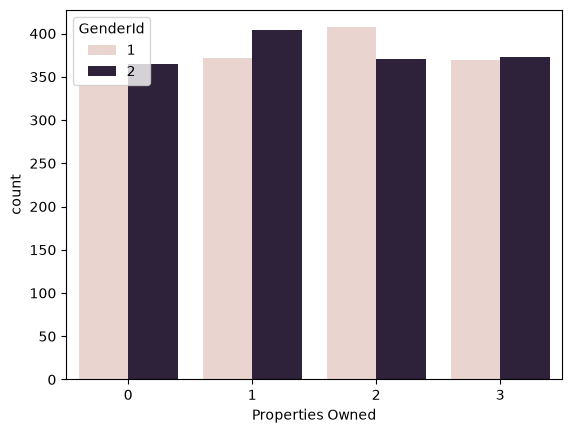

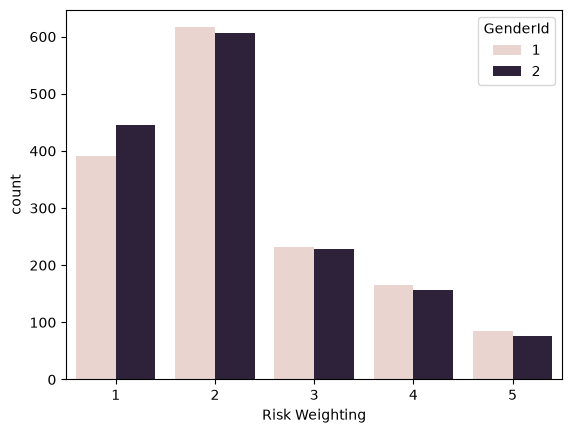

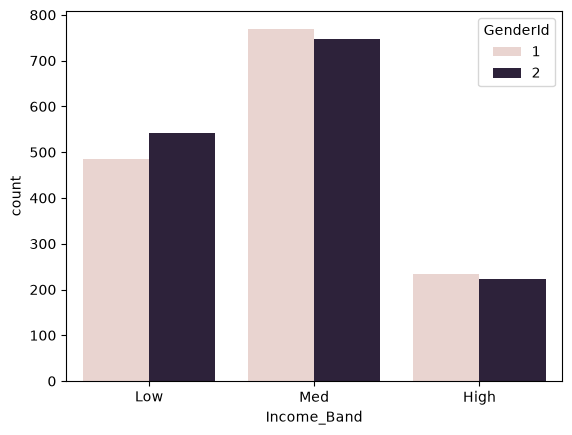

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
for i,predictor in enumerate(df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification","Properties Owned","Risk Weighting","Income_Band"]].columns):
    plt.figure(i)
    sns.countplot(data=df,x=predictor,hue='GenderId')

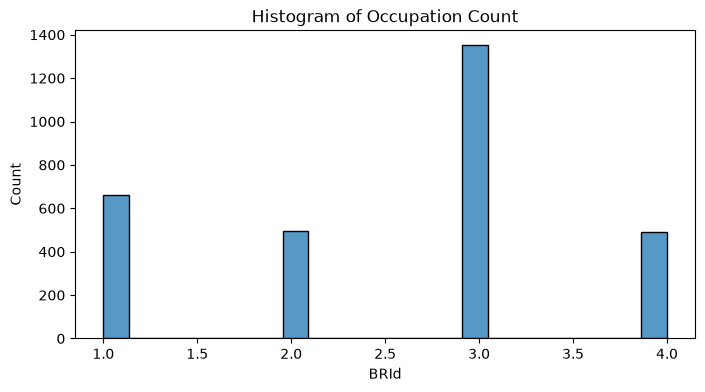

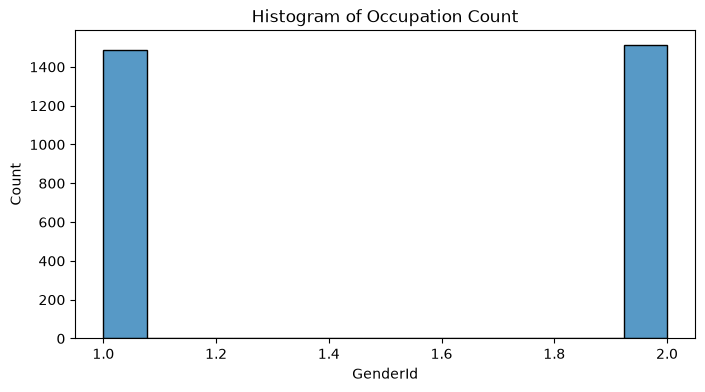

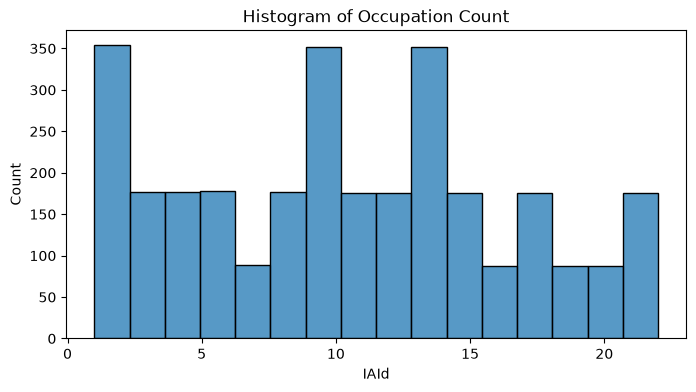

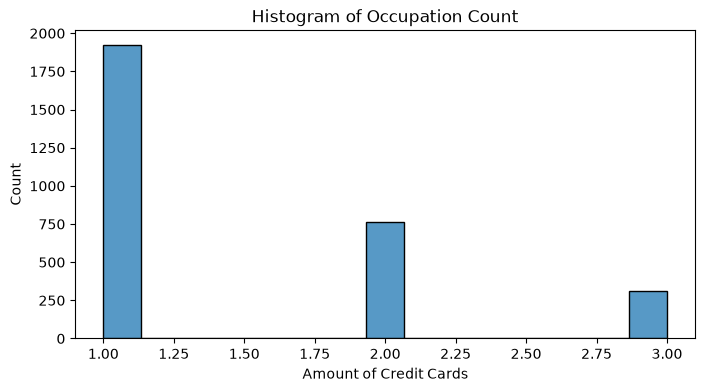

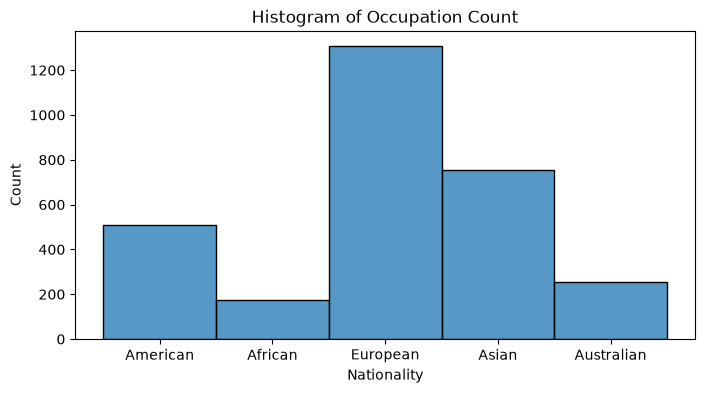

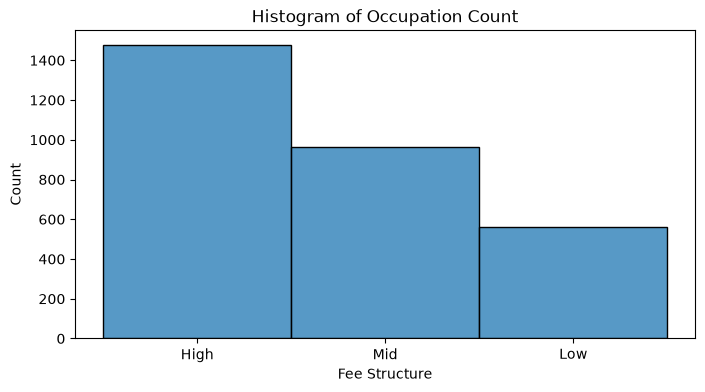

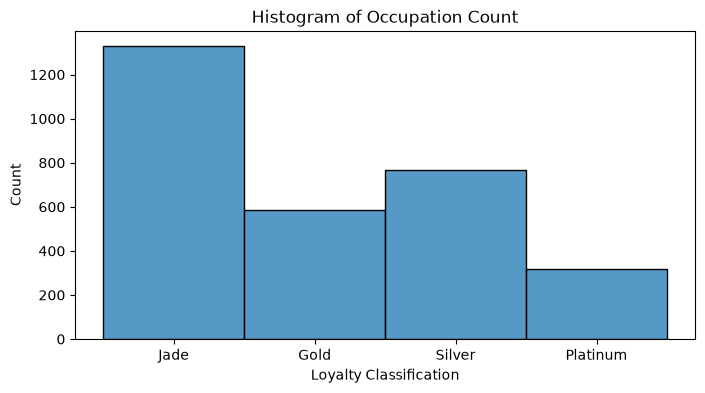

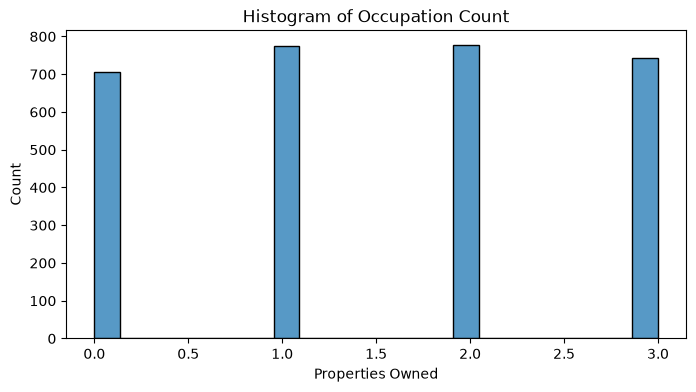

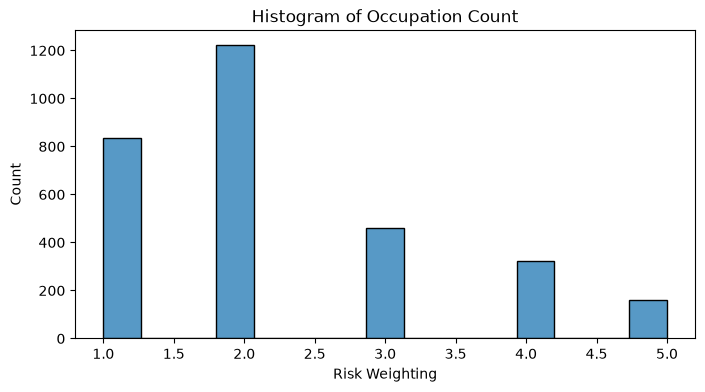

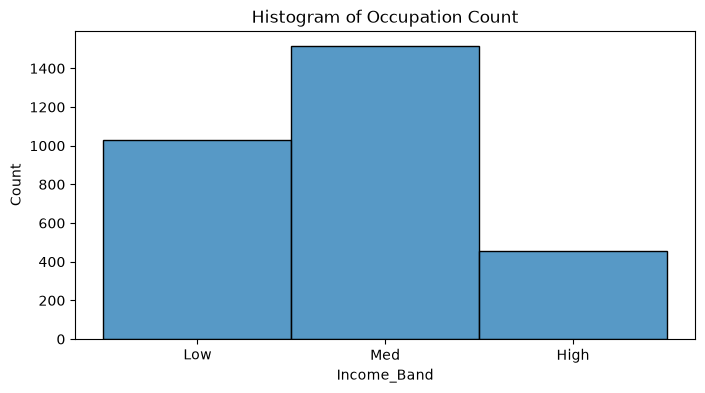

In [12]:
for col in categorical_cols:
    if col=='Occupation':
        continue
    plt.figure(figsize=(8,4))
    sns.histplot(df[col])
    plt.title("Histogram of Occupation Count")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


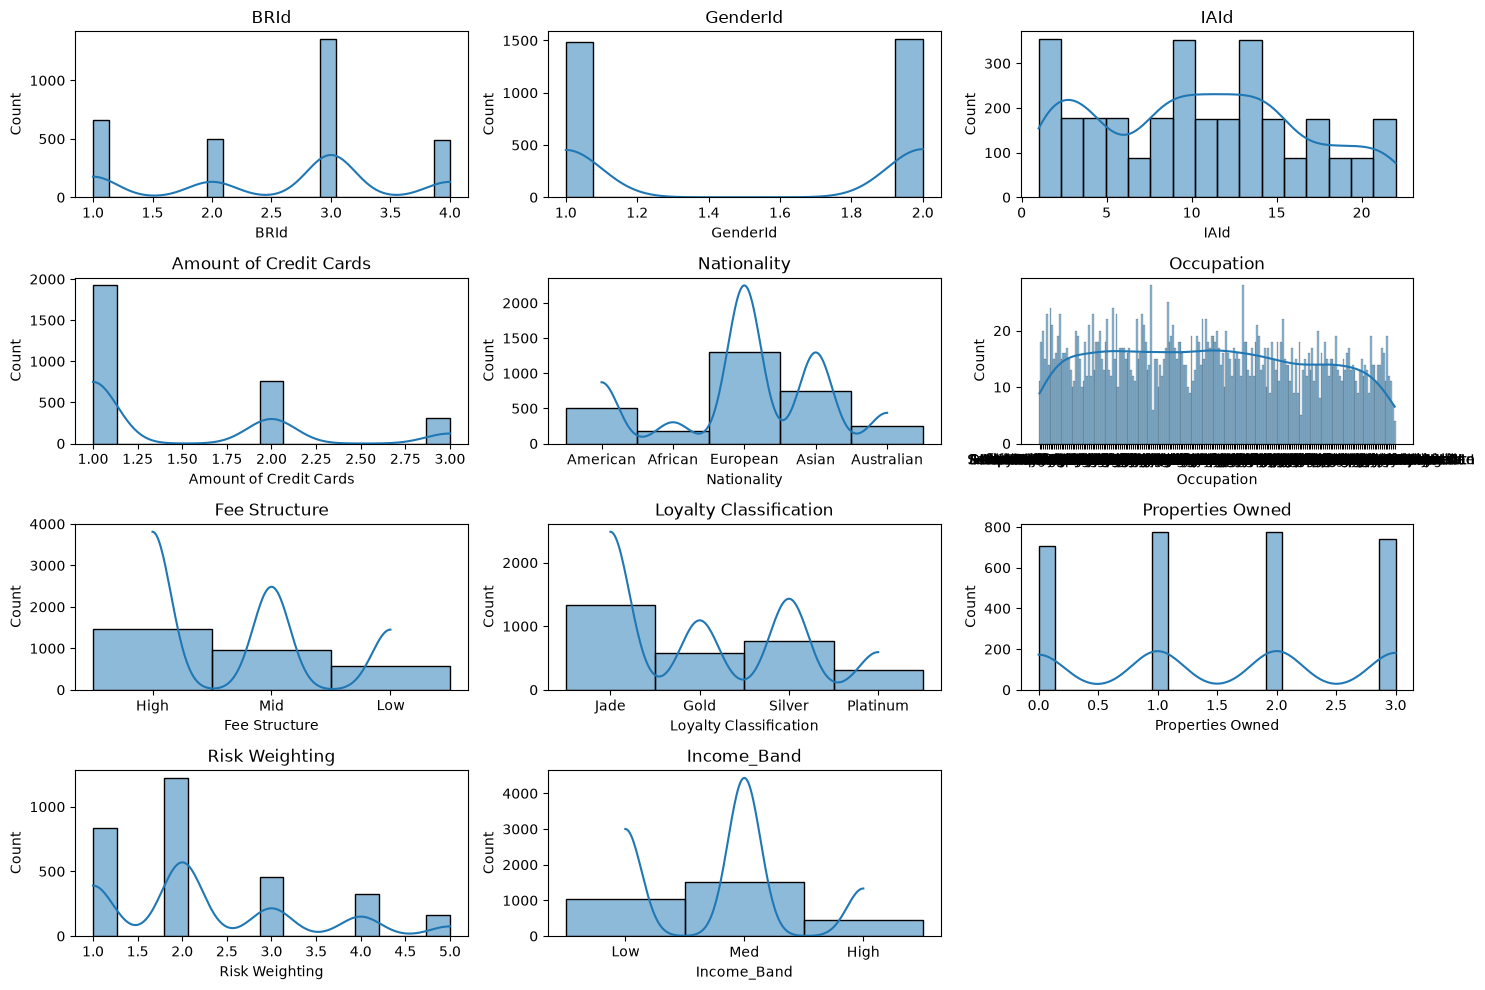

In [14]:

plt.figure(figsize=(15, 10)) 
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
    
plt.tight_layout()  # Recommended: prevents titles/labels from overlapping
plt.show()


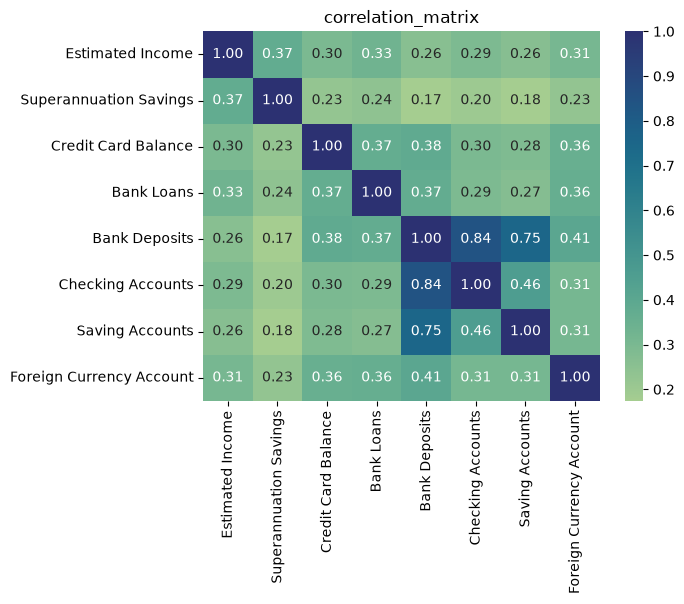

In [15]:
numerical_cols = ['Estimated Income', 'Superannuation Savings','Credit Card Balance','Bank Loans','Bank Deposits','Checking Accounts','Saving Accounts','Foreign Currency Account']
correlation_matrix=df[numerical_cols].corr()
plt.Figure(figsize=(12,12))
sns.heatmap(correlation_matrix,annot=True,cmap='crest',fmt='.2f')
plt.title("correlation_matrix")
plt.show()

In [16]:
#Insights of EDA:
#The strongest positive correlation occur among "Bank Deposits" with "Checking Accounts", "Saving Accounts" and 
#"Foreign Currency Account indicating that customers who maintain high balances in one account type often hold substantial amount/funds across other accounts as well.